# Implementing a Multilayer Neural Network from Scratch
## Task 1: Dataset Preparation and Normalization

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X= X.values
X = ((X / 255.) - 0.5) * 2  # Normalize to [-1, 1]
y = y.astype(int).to_numpy()
print(X.shape, y.shape)

(70000, 784) (70000,)


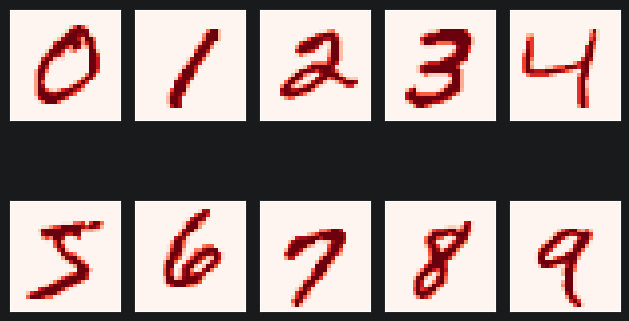

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Reds')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

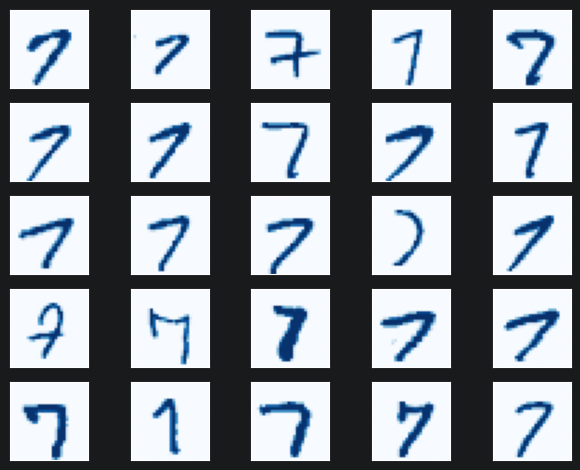

In [3]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Blues')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()

## Task 2: Implementing the Neural Network

In [4]:
def sigmoid(z):
    return 1. / (1. + np.exp(-z))

class NeuralNetMLP:
    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        rng = np.random.RandomState(random_seed)
        self.weight_h = rng.normal(loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)
        self.weight_out = rng.normal(loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)

    def forward(self, X):
        z_h = np.dot(X, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out


In [5]:
model = NeuralNetMLP(num_features=28*28,
                     num_hidden=50,
                     num_classes=10)

## Task 3: Backpropagation and Training

In [6]:
def int_to_onehot(y, num_labels):
    onehot = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        onehot[i, val] = 1
    return onehot

def backward(X, a_h, a_out, y, weight_out, weight_h):
    y_onehot = int_to_onehot(y, a_out.shape[1])

    delta_out = (2 * (a_out - y_onehot) / y.shape[0] * a_out * (1 - a_out))
    d_weight_out = np.dot(delta_out.T, a_h)

    delta_h = np.dot(delta_out, weight_out) * a_h * (1 - a_h)
    d_weight_h = np.dot(delta_h.T, X)

    return d_weight_h, d_weight_out

## Task 4: Training the Model with Mini-Batch Gradient Descent

In [7]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)

    for i, (features, targets) in enumerate(minibatch_gen):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)

        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas) ** 2)
        correct_pred += (predicted_labels == targets).sum()

        num_examples += targets.shape[0]
        mse += loss

    mse = mse / (i + 1)
    acc = correct_pred / num_examples
    return mse, acc



In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=10000, random_state=123)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=5000, random_state=123)

In [9]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

In [10]:
def minibatch_generator(X, y, batch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, X.shape[0] - batch_size + 1, batch_size):
        batch_indices = indices[start_idx:start_idx + batch_size]
        yield X[batch_indices], y[batch_indices]

def train_model(X_train, y_train, X_valid, y_valid, model, num_epochs, batch_size, learning_rate):
    epoch_train_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    epoch_valid_loss = []
    for epoch in range(num_epochs):
        minibatch_gen = minibatch_generator(X_train, y_train, batch_size)
        for X_mini, y_mini in minibatch_gen:
            a_h, a_out = model.forward(X_mini)
            d_weight_h, d_weight_out = backward(X_mini, a_h, a_out, y_mini, model.weight_out, model.weight_h)
            model.weight_h -= learning_rate * d_weight_h
            model.weight_out -= learning_rate * d_weight_out

        # Evaluate loss and accuracy after each epoch
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_train_loss.append(train_mse)
        epoch_valid_loss.append(valid_mse)
        print(f'Epoch {epoch + 1} completed')
        print(f'| Train MSE: {train_mse:.2f} '
              f'| Valid MSE: {valid_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')
    return epoch_train_loss, epoch_valid_loss, epoch_train_acc, epoch_valid_acc

train_loss, valid_loss, train_acc, valid_acc = train_model(
    X_train,
    y_train,
    X_valid,
    y_valid,
    model,
    num_epochs=50,
     batch_size=100,
    learning_rate=0.1
)

Epoch 1 completed
| Train MSE: 0.05 | Valid MSE: 0.05 | Train Acc: 76.71% | Valid Acc: 77.28%
Epoch 2 completed
| Train MSE: 0.03 | Valid MSE: 0.03 | Train Acc: 85.43% | Valid Acc: 85.88%
Epoch 3 completed
| Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 88.03% | Valid Acc: 88.28%
Epoch 4 completed
| Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 89.17% | Valid Acc: 89.44%
Epoch 5 completed
| Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 90.17% | Valid Acc: 90.36%
Epoch 6 completed
| Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 90.77% | Valid Acc: 90.80%
Epoch 7 completed
| Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 91.15% | Valid Acc: 91.12%
Epoch 8 completed
| Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 91.45% | Valid Acc: 91.50%
Epoch 9 completed
| Train MSE: 0.01 | Valid MSE: 0.01 | Train Acc: 91.73% | Valid Acc: 91.74%
Epoch 10 completed
| Train MSE: 0.01 | Valid MSE: 0.01 | Train Acc: 92.07% | Valid Acc: 92.00%
Epoch 11 completed
| Train MSE: 0.01 | Valid MSE: 0.01 | Tr

In [11]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)

print(f'Test MSE: {test_mse:.2f}')
print(f'Test accuracy: {test_acc * 100:.2f}%')

Test MSE: 0.01
Test accuracy: 94.78%


## Task 5: Visualizing Results

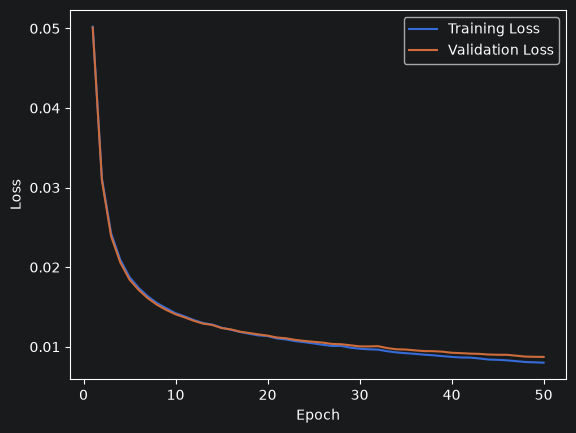

In [12]:
import matplotlib.pyplot as plt
num_epochs=50
# Plotting the loss and accuracy curves
plt.plot(range(1, num_epochs+1), train_loss, label='Training Loss')
plt.plot(range(1, num_epochs+1), valid_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Visualize misclassified examples
def visualize_misclassified(X, y_true, y_pred):
    misclassified_idx = np.where(y_true != y_pred)[0]
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(misclassified_idx):
            idx = misclassified_idx[i]
            ax.imshow(X[idx].reshape(28, 28), cmap='gray')
            ax.set_title(f'True: {y_true[idx]}, Pred: {y_pred[idx]}')
            ax.axis('off')
    plt.show()


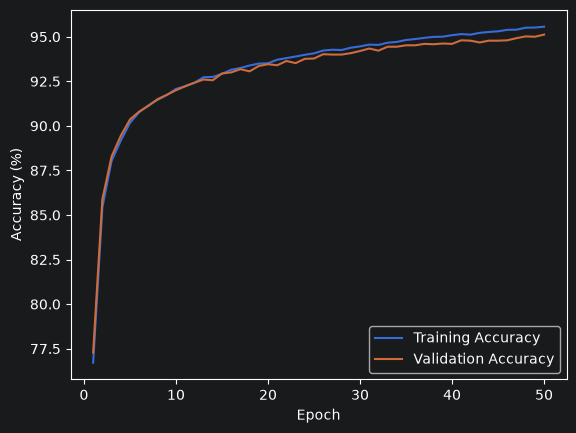

In [13]:
plt.plot(range(1, num_epochs + 1), train_acc, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), valid_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

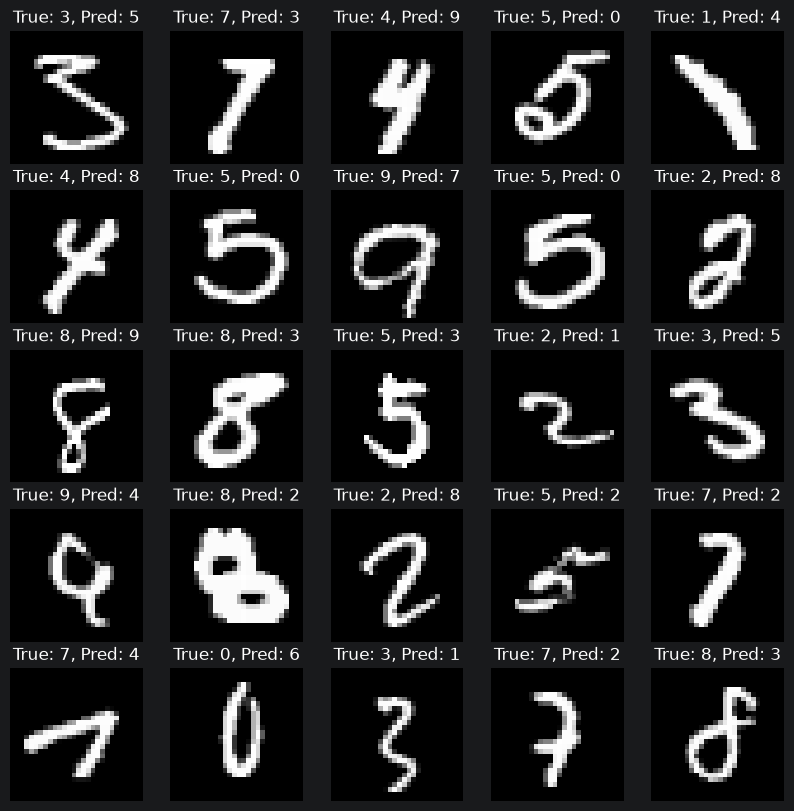

In [15]:
_, test_probas = model.forward(X_test)
y_test_pred = np.argmax(test_probas, axis=1)

visualize_misclassified(X_test, y_test, y_test_pred)